In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA
from scipy.stats import norm
from datetime import datetime

from src.cbr_parser import CBRParser
from src.data_handler import DataHandler
from src.classical_models import ClassicModel
from src.testing_framework import UnifiedTestingFramework

In [2]:
TENOR_YEARS = {'1W': 7/365, '2W': 14/365, '1M': 30/365, '2M': 60/365, '3M': 90/365, '6M': 180/365, '1Y': 1.0, '2Y': 2.0}
ROISFIX = DataHandler.from_excel('data/roisfix.xlsx').clean()

### Explanatory Data Analysis

In [3]:
ROISFIX.descriptive_statistics(caption='ROISfix Descriptive Statistics', style=True)

,1W,2W,1M,2M,3M,6M,1Y,2Y
count,3708.0000,3708.0000,3708.0000,3708.0000,3708.0000,3708.0000,2499.0000,995.0000
mean,9.4823,9.5115,9.5552,9.5882,9.6098,9.6587,10.5029,13.7736
std,4.6535,4.6731,4.7193,4.7321,4.7323,4.7512,4.9774,4.1968
min,3.0800,3.0900,3.1800,3.2400,3.3000,3.4900,4.1400,8.3500
25%,6.1000,6.1000,6.0900,6.0800,6.0875,6.1000,7.1500,9.2450
50%,7.6300,7.6300,7.6700,7.7400,7.8200,7.9800,8.5000,13.5900
75%,11.2325,11.2200,11.2200,11.2000,11.1725,11.0700,14.4000,16.7550
max,22.8500,23.9200,25.1500,25.0600,25.1800,26.7100,26.5300,25.2000
skew,1.0596,1.0733,1.1137,1.1375,1.1624,1.2435,1.1352,0.5793
kurtosis,0.1351,0.1757,0.3206,0.4125,0.5123,0.8565,0.5426,-0.3301


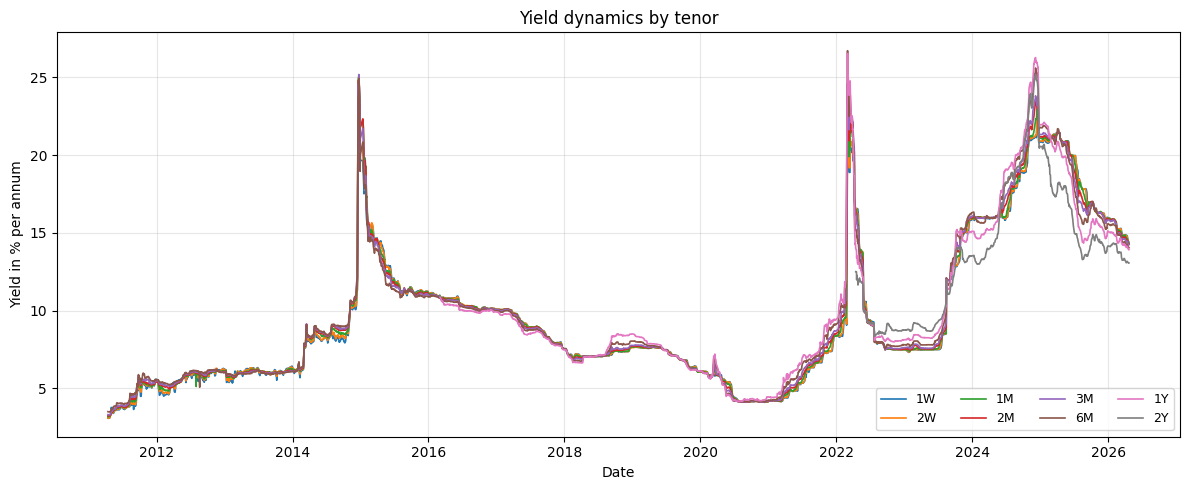

In [4]:
ROISFIX.plot_time_series()

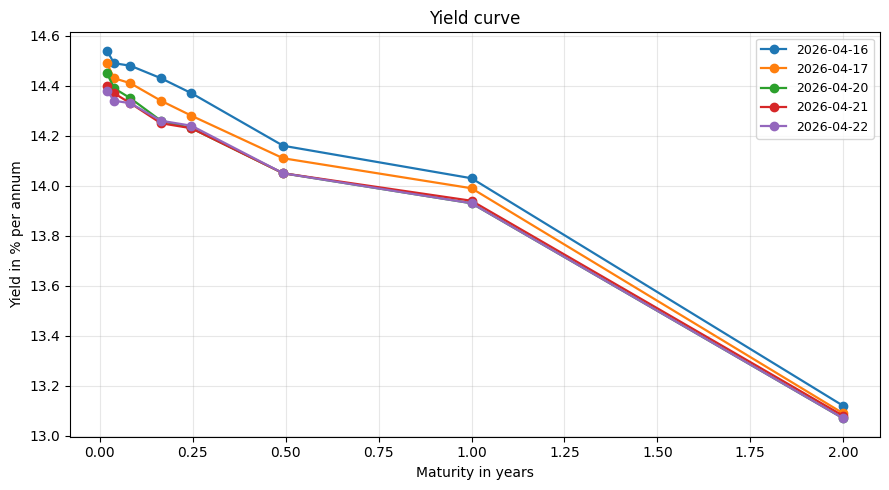

In [5]:
ROISFIX.plot_yield_curves(dates=None)

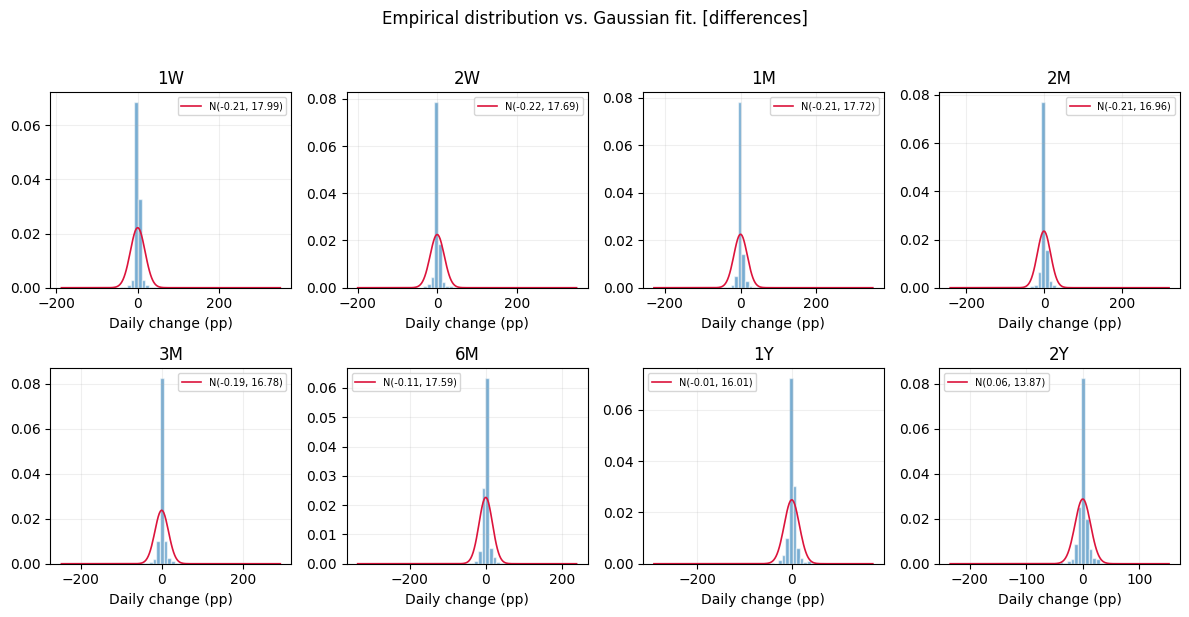

In [6]:
ROISFIX.plot_distributions(which='differences')

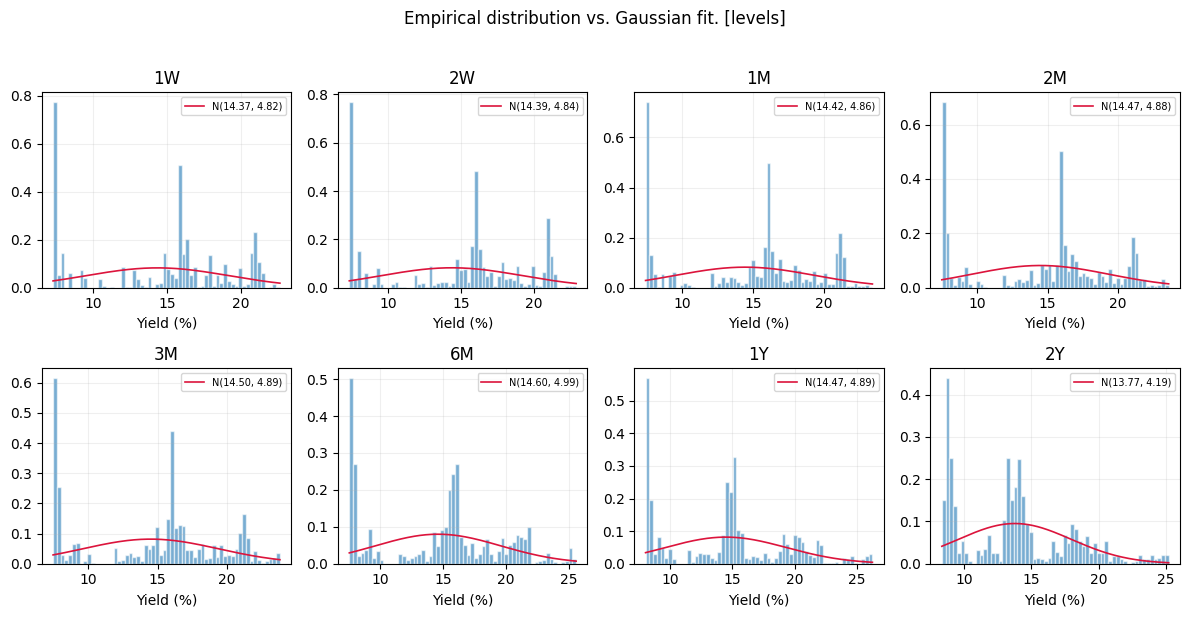

In [7]:
ROISFIX.plot_distributions(which='levels')

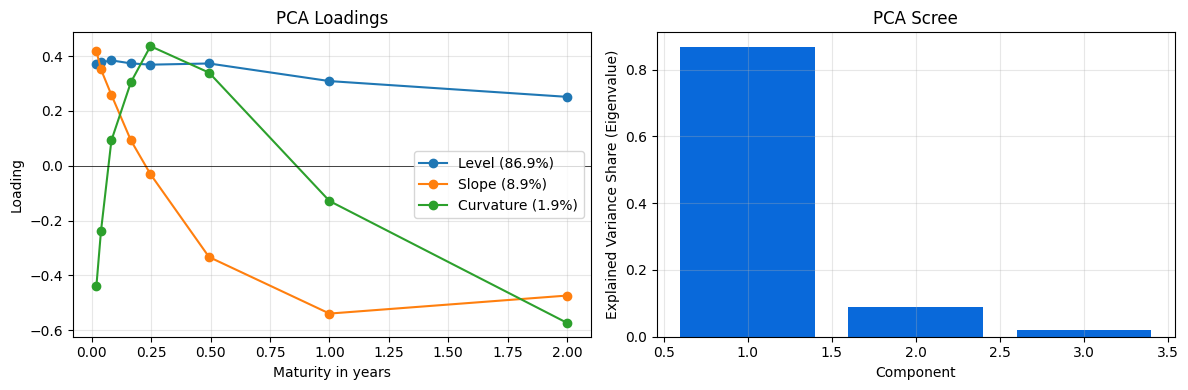

In [8]:
ROISFIX.plot_pca_decomposition(n_components=3)

### Classical Models: Calibration

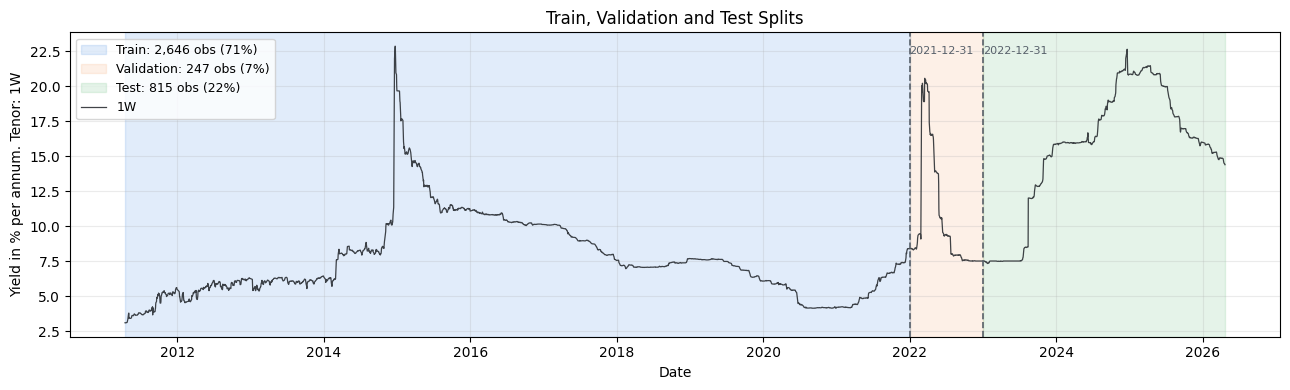

In [9]:
train, val, test = ROISFIX.train_val_test_split(train_end='2021-12-31', val_end='2022-12-31', plot=True)
train = train.drop(columns=['2Y'])

In [10]:
vasicek = ClassicModel('vasicek').calibrate(train['1M']) # fits one tenor
vasicek.display_params()
# vasicek.simulate(T=1/12, n_paths=500)

kappa,0.489338
theta,8.5964
sigma,2.4638
r0,8.3700


In [11]:
hw = ClassicModel('hull-white').calibrate(train['1M']) # fits one tenor
hw.display_params()

a,0.489338
sigma,2.4638
theta_t (summary),"len=2646, mean=4.2060, std=34.5151"
r0,8.3700


In [12]:
maturities = list(TENOR_YEARS.values())[:-1]

ns = ClassicModel('nelson-siegel').calibrate(train.iloc[-1], taus=maturities) # fits the last row
ns.display_params()

beta0,-73.0905
beta1,81.3730
beta2,100.0000
lambda,0.213485


In [13]:
dns = ClassicModel('dns').calibrate(train, taus=maturities) # fits whole matrix
dns.display_params()

lambda,0.730800
mu,"[0.1981, -0.2010, -0.2069]"
A (summary),"len=9, mean=0.3337, std=0.4635"
Sigma (summary),"len=9, mean=0.2214, std=1.3811"
beta_last,"[6.6882, 1.5927, 7.1852]"
r0,8.3800


### Classical Models: Simulation

In [14]:
NPATHS = 10_000 # num. of simulations
T = 1 # for simulation of 1 year, 250 business days

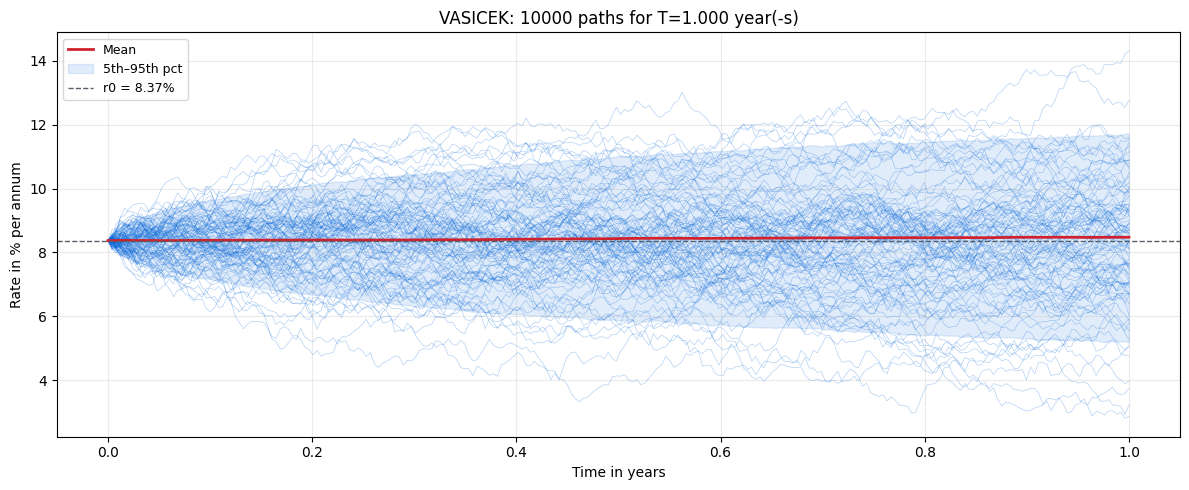

In [15]:
paths_vasicek = vasicek.simulate(T=T, n_paths=NPATHS, n_show=100)

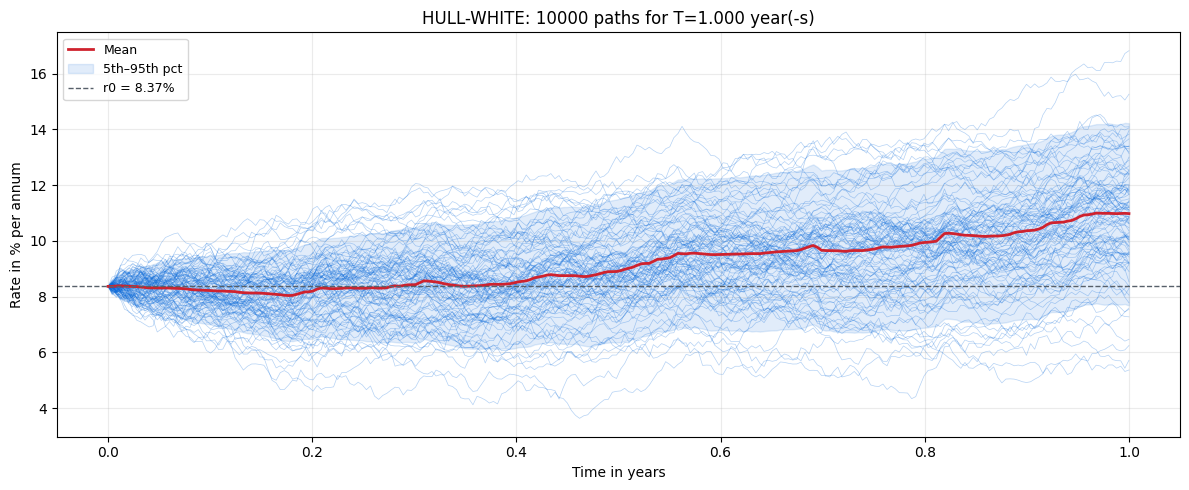

In [16]:
paths_hw = hw.simulate(T=T, n_paths=NPATHS, n_show=100)

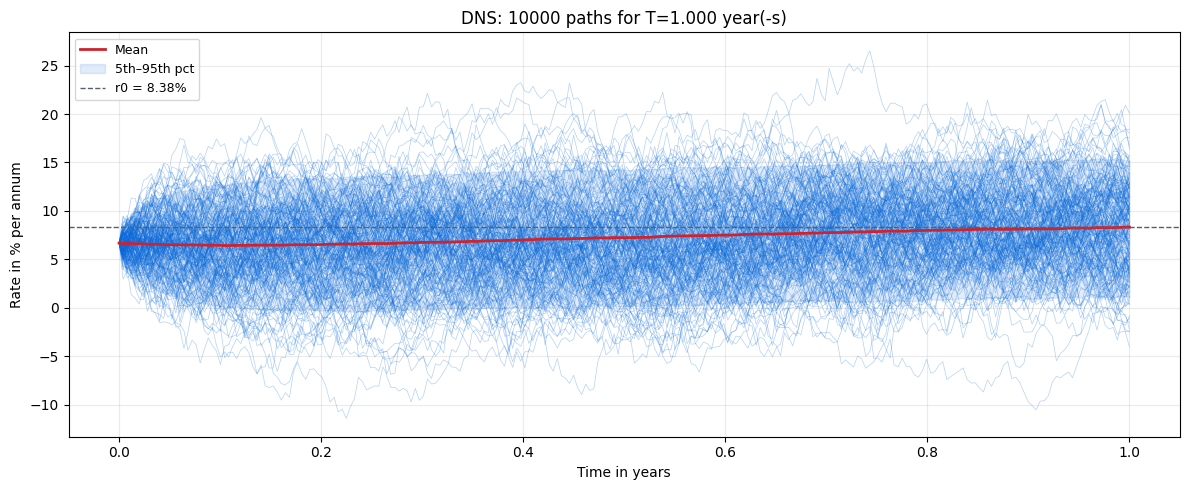

In [17]:
paths_dns = dns.simulate(T=T, n_paths=NPATHS, n_show=200)